In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [137]:
df=pd.read_csv('Resume.csv')
df

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR
...,...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION


In [138]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [139]:
df.shape

(2484, 4)

In [140]:
df['ID'].nunique()

2484

In [141]:
df=df.drop(['ID','Resume_html'],axis=1)

In [142]:
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

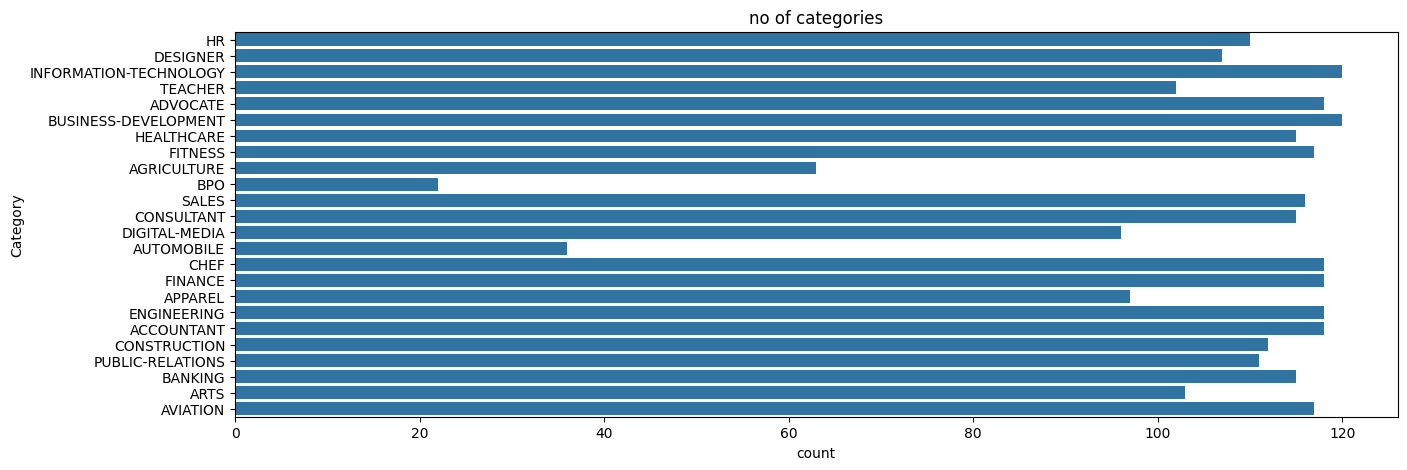

In [143]:
plt.figure(figsize=(15,5))
sns.countplot(df['Category'])
plt.title('no of categories')
plt.show()

In [144]:
df['Category'].unique()

<StringArray>
[                    'HR',               'DESIGNER', 'INFORMATION-TECHNOLOGY',
                'TEACHER',               'ADVOCATE',   'BUSINESS-DEVELOPMENT',
             'HEALTHCARE',                'FITNESS',            'AGRICULTURE',
                    'BPO',                  'SALES',             'CONSULTANT',
          'DIGITAL-MEDIA',             'AUTOMOBILE',                   'CHEF',
                'FINANCE',                'APPAREL',            'ENGINEERING',
             'ACCOUNTANT',           'CONSTRUCTION',       'PUBLIC-RELATIONS',
                'BANKING',                   'ARTS',               'AVIATION']
Length: 24, dtype: str

In [145]:
import re

def clean_resume(text):
    # 1. Convert to lowercase for uniformity
    text = text.lower()

    # 2. Remove URLs (http, https, www)
    text = re.sub(r'http\S+\s*', ' ', text)

    # 3. Remove 'RT' and 'cc' (common in social-shared resumes/text)
    # \b ensures we only match the whole word, not letters inside "start" or "account"
    text = re.sub(r'\bRT\b|\bcc\b', ' ', text)

    # 4. Remove hashtags (#Python) and mentions (@User)
    text = re.sub(r'#\S+', ' ', text)
    text = re.sub(r'@\S+', ' ', text)

    # 5. Remove punctuations and special characters
    # This keeps only alphanumeric characters and spaces
    text = re.sub(r'[^\w\s]', ' ', text)

    # 6. Remove non-ASCII characters (like emojis or special bullets)
    text = re.sub(r'[^\x00-\x7f]', ' ', text)

    # 7. Remove extra whitespace and newlines
    text = re.sub(r'\s+', ' ', text)

    return text




In [146]:
df['Resume_str']=df['Resume_str'].apply(lambda x:clean_resume(x))
df['Resume_str']

0        hr administrator marketing associate hr admin...
1        hr specialist us hr operations summary versat...
2        hr director summary over 20 years experience ...
3        hr specialist summary dedicated driven and dy...
4        hr manager skill highlights hr skills hr depa...
                              ...                        
2479     rank sgt e 5 non commissioned officer in char...
2480     government relations communications and organ...
2481     geek squad agent professional profile it supp...
2482     program director office manager summary highl...
2483     storekeeper ii professional summary the purpo...
Name: Resume_str, Length: 2484, dtype: str

## words in categorical form

In [147]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit(df['Category'])
df['Category']=le.transform(df['Category'])

In [148]:
df.head()

,Resume_str,Category
0,hr administrator marketing associate hr admin...,19
1,hr specialist us hr operations summary versat...,19
2,hr director summary over 20 years experience ...,19
3,hr specialist summary dedicated driven and dy...,19
4,hr manager skill highlights hr skills hr depa...,19


### vectorization

In [149]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english')
tfidf.fit(df['Resume_str'])
requiredtext=tfidf.transform(df['Resume_str'])

In [150]:
requiredtext.shape

(2484, 40029)

### splitting

In [151]:
x=requiredtext
y=df['Category']
x.shape

(2484, 40029)

In [152]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [153]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsRestClassifier


In [154]:
clf=OneVsRestClassifier(KNeighborsClassifier())


In [155]:
clf.fit(x_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",KNeighborsClassifier()
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [156]:
y_pred=clf.predict(x_test)
print(y_pred)

[23 14 11 10  7  9 13  9 23 13 11 18 22  8  1 18  5  1  3  3  3 19 13  7
 14  9  3  9 12 18  5 18  0  9  4 12 18 10 15 17  3 20 13 20 19  0  4 11
 10  9  6 12 10 18  1  9  9  1  3 21  9 10 12 20  4  9 18 23 18 11 15 22
 21 22  6  6 20 16 22 20 23  0 10  6  9  6 18 23 21 11 15  0 12 19 22 18
  0 23  0  0  7  3 23 14 12  1 14 18  5  5 15 23 18 18  7 16 21 11 14 11
 14  7 18  8 18  1  0  4  1  9 18  1  2 11  1  6  4  1 22  9  1 18 11  9
 20 21 13  4 15 18  7  9 18  9  9  6 20 21 11 23  3  3 11  7  9 22  1 22
  3  3  0  1 14  1  1 21  6 22 19 15  1 22  1 20  4 12 13  9  1 15  1  1
  3 10  9 17 22 12  7 15 18  9  6 15  3  0 20 20 16  6  3 23 15  0  0  0
  0  6 11  0 10  1  4 18 10 20  3 19  6  0 14 13  6 15 16  0  1  7 23  3
 15  9  9  0  1 22 20  4 12 16 21  9  9  9  6 14 13 13 18  3  7 11 14 21
 20  7 14 22 11  7  1  1 21  1  3 16 23 10  1  1  2 20 21  8 13  3  4 15
 14 18 10  9 21  0 22  9 13 12 14 11 23  1 21  9 20  9 11 19  1 21 23 19
 12  9 15  9 19  9 22 17 22 23 16  1  6 13 11 18 10

In [157]:
accuracy=accuracy_score(y_pred,y_test)
accuracy

0.49390243902439024

In [158]:
clf=OneVsRestClassifier(KNeighborsClassifier(n_neighbors=7, metric='cosine'))
clf.fit(x_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",KNeighborsCla...n_neighbors=7)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [159]:
y_pred=clf.predict(x_test)
print(y_pred)

[23 14 11 10  7 17 13  9 23 13 15 18  1 20  1 18 15  1  3  3  3 19 13  7
 14  9  3  9 12 18  5 18  0  9  4 12 18 10  6 17  3 20 13 20 19  0 23 11
 10  9  6 20 10 18  1  9  9  1 11 21  3 10 20 20 22  9 18 23 18 11 15 22
 21  3  6  6 20 16 22 20 23  0 10  6  9  6 18 23 21 11 15  0 12 19 22 18
  0 23  0  0  7  3 23 14 12  1 14 18  1  1 15 23 18 18  7 16 21 11 14 11
 14  7 18 12 18  1  0 13  1  9  1  1  2 11  1 16  1 14 22  9  1 18 11  9
 20 21 13 23 15 19  7  9 18  9  9  6 20 21  6 23 14  3 11  7  7 22  1 22
  1  3  0  1 14  1  1 21  3 22 19 15  1  1 22  1 13 12 13 13  3 15  1  1
 13 10 16 17 22 20  2 15 18  9  6 15 11  0 20 20  0 15  3 23 12  0  0  0
  0  6 11  1 10  1 14 19 10 20  9 19  6  0 14 13 20 15 16  0  1  7 23  3
 11 14  9  0  1 22 20  6 12 16 21  9 22  1  6 14 13 13 18  3  7 11 14 21
 12  7 14 22 11  7 18  1 21  1  3 16  4 10  1  1  2 20 21 12 13  3 13 15
 14 18 10  9 21  0  1  9 13 20 14 11  1 18 21  9 20  1 11 19  1 14 23 19
 20 12 15  9 19  9 22 17 22 23 16 22 12 13 11 18 10

In [160]:
accuracy=accuracy_score(y_pred,y_test)
accuracy

0.5341463414634147

In [161]:
clf=KNeighborsClassifier()
clf.fit(x_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [162]:
y_pred=clf.predict(x_test)
print(y_pred)

[23 14 11 10  7  9 13  9 23 13 11 18 22  8  1 18  5  1  3  3  3 19 13  7
 14  9  3  9 12 18  5 18  0  9  4 12 18 10 15 17  3 20 13 20 19  0  4 11
 10  9  6 12 10 18  1  9  9  1  3 21  9 10 12 20  4  9 18 23 18 11 15 22
 21 22  6  6 20 16 22 20 23  0 10  6  9  6 18 23 21 11 15  0 12 19 22 18
  0 23  0  0  7  3 23 14 12  1 14 18  5  5 15 23 18 18  7 16 21 11 14 11
 14  7 18  8 18  1  0  4  1  9 18  1  2 11  1  6  4  1 22  9  1 18 11  9
 20 21 13  4 15 18  7  9 18  9  9  6 20 21 11 23  3  3 11  7  9 22  1 22
  3  3  0  1 14  1  1 21  6 22 19 15  1 22  1 20  4 12 13  9  1 15  1  1
  3 10  9 17 22 12  7 15 18  9  6 15  3  0 20 20 16  6  3 23 15  0  0  0
  0  6 11  0 10  1  4 18 10 20  3 19  6  0 14 13  6 15 16  0  1  7 23  3
 15  9  9  0  1 22 20  4 12 16 21  9  9  9  6 14 13 13 18  3  7 11 14 21
 20  7 14 22 11  7  1  1 21  1  3 16 23 10  1  1  2 20 21  8 13  3  4 15
 14 18 10  9 21  0 22  9 13 12 14 11 23  1 21  9 20  9 11 19  1 21 23 19
 12  9 15  9 19  9 22 17 22 23 16  1  6 13 11 18 10

In [163]:
accuracy=accuracy_score(y_pred,y_test)
accuracy

0.49390243902439024

In [164]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier

# Linear kernel is almost always best for text data
clf = SVC(kernel='linear', C=1.0, probability=True)
clf.fit(x_train, y_train)

# Check the new accuracy
new_prediction = clf.predict(x_test)
print(f'New Accuracy: {accuracy_score(y_test, new_prediction):.2%}')

New Accuracy: 60.12%


In [165]:
import pickle
pickle.dump(requiredtext,open('requiredtext.pkl','wb'))
pickle.dump(tfidf,open('tfidf.pkl','wb'))
pickle.dump(clf,open('clf.pkl','wb'))


